C:\Users\admin\AppData\Local\Temp\ipykernel_15024\2780133179.py:17: FutureWarning: In a future version of pandas all arguments of DataFrame.pivot will be keyword-only.
  precipitation = df.pivot("Latitude", "Longitude", "Total_Precipitation").values
c:\Users\admin\miniconda3\envs\tf\lib\site-packages\geopandas\tools\clip.py:67: FutureWarning: In a future version, `df.iloc[:, i] = newvals` will attempt to set the values inplace instead of always setting a new array. To retain the old behavior, use either `df[df.columns[i]] = newvals` or, if columns are non-unique, `df.isetitem(i, newvals)`
  clipped.loc[


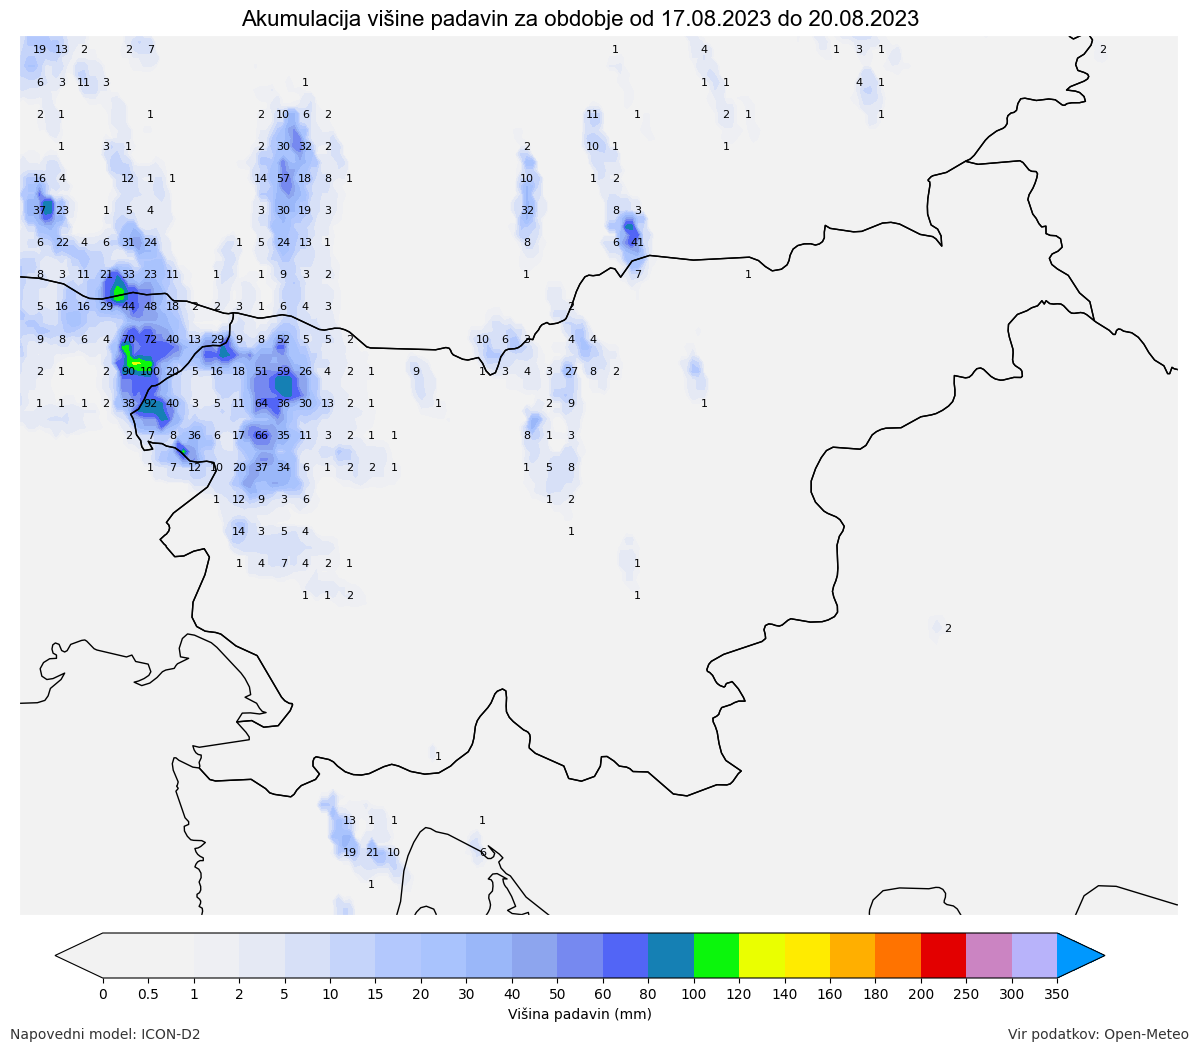

In [57]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from shapely.geometry import Polygon, Point
import numpy as np
import matplotlib.colors as mcolors
import matplotlib.image as mpimg
from scipy.ndimage import zoom
import matplotlib.patches as patches

# Enhanced colormap with more detailed gradient
colors = ["#f2f2f2","#b5c9fd","#9fbefd","#889eea","#6171f7","#3e55f4","#009694","#0cff00","#e6ff00","#ffff00","#ffcf00","#ff9f00","#ff6f00","#ff1b00","#e60000","#cc0000","#a600a4","#c27ec1","#e094c3","#ffbffd","#f5a6f9","#6fc3fb","#0098fe"]
cmap_custom = mcolors.LinearSegmentedColormap.from_list('custom_cmap', colors, N=300)

# Read the precipitation data
df = pd.read_csv('../data/test/precipitation/precipitation_data_2023-08-17_to_2023-08-20_20230817132327.csv')
precipitation = df.pivot("Latitude", "Longitude", "Total_Precipitation").values

lat_values = df['Latitude'].unique()
lon_values = df['Longitude'].unique()

# Load the world map with medium resolution
world = gpd.read_file('../data/shapes/shape/ne_10m_admin_0_countries/ne_10m_admin_0_countries.shp')

# Define the neighboring countries
countries = ['Slovenia', 'Austria', 'Italy', 'Hungary', 'Croatia']

# Filter the neighboring countries
region = world[world['NAME'].isin(countries)]

# Create bounding box for the region
latitude_center, longitude_center = 46.1512, 14.9955
lat_min = latitude_center - 1
lat_max = latitude_center + 1
lon_min = longitude_center - 2
lon_max = longitude_center + 1.80

bbox_polygon = Polygon([(lon_min, lat_min), (lon_min, lat_max), (lon_max, lat_max), (lon_max, lat_min)])

# Adjust the bounding box of the region to match the defined bounding box
region_clipped = gpd.clip(region, bbox_polygon)

# Plot the bounding areas with detailed geometries
fig, ax = plt.subplots(figsize=(15, 15))
region_clipped.plot(ax=ax, color='lightgrey', edgecolor='black')
gpd.GeoSeries(bbox_polygon).boundary.plot(ax=ax, color='red', linestyle='--')

# Clip precipitation values within the desired range
precipitation_clipped = np.clip(precipitation, 0, 350) # Adjust max value to match contour levels
# Define the specific contour levels
contour_levels = [0, 0.5, 1, 2, 5, 10, 15, 20, 30, 40, 50, 60, 80, 100, 120, 140, 160, 180, 200, 250, 300, 350]

# Identify the maximum precipitation value and its coordinates
max_precip = precipitation_clipped.max()
max_precip_coords = np.unravel_index(precipitation_clipped.argmax(), precipitation_clipped.shape)

# Use the custom colormap in the contour plot
contour_plot = ax.contourf(lon_values, lat_values, precipitation_clipped, levels=contour_levels, cmap=cmap_custom, extend='both')

# Optionally, set stride to control the density of the text
stride = 4

# Iterate through the grid and add text for precipitation values
for i in range(0, len(lat_values), stride):
    for j in range(0, len(lon_values), stride):
        # Skip values outside of the bounding box
        if not bbox_polygon.contains(Point(lon_values[j], lat_values[i])):
            continue
        # Extract precipitation value and convert to integer
        precip_val = int(round(precipitation_clipped[i, j]))
        # Always plot the maximum value
        if (i, j) == max_precip_coords or precip_val != 0:
            ax.text(lon_values[j], lat_values[i], f'{precip_val}', fontsize=8, ha='center', va='center', color='black')
            
# Add borders between countries
region_clipped.boundary.plot(ax=ax, linewidth=1, color='black')

plt.xlim(lon_min, lon_max)
plt.ylim(lat_min, lat_max)


# Remove x and y axis
plt.xticks([])
plt.yticks([])

# Load and resize the logo (replace 'logo.png' with your actual logo path)
logo = mpimg.imread('../assets/logo/logo.png')

# Scale down the logo by a factor; you can adjust this value
scaling_factor = 0.1
logo_resized = zoom(logo, (scaling_factor, scaling_factor, 1))

# Add the logo to the figure; adjust coordinates to place at the top left
fig.figimage(logo_resized, xo=10, yo=fig.bbox.ymax - logo_resized.shape[0] - 10, zorder=10)

# Set a more modern-looking title using fig.text, and you can manually control the position
title_font = {'fontname':'Arial', 'size':'16', 'color':'black', 'weight':'light'}
fig.text(0.5, 0.795, "Akumulacija višine padavin za obdobje od 17.08.2023 do 20.08.2023", ha='center', **title_font)

# Add the source at the bottom of the figure
fig.text(0.906, 0.12, "Vir podatkov: Open-Meteo", ha="right", fontsize=10, color="#333333")

# Add the source at the bottom of the figure
fig.text(0.12, 0.12, "Napovedni model: ICON-D2", ha="left", fontsize=10, color="#333333")

# Create axes for the colorbar to make it the same width as the plot, and place at the very bottom
cax = fig.add_axes([0.15, 0.16, 0.7, 0.03])
cbar = plt.colorbar(contour_plot, cax=cax, orientation='horizontal', ticks=contour_levels, label="Višina padavin (mm)")

# Format the tick labels to display integers except for 0 and 0.5
tick_labels = [str(int(level)) if level not in [0, 0.5] else str(level) for level in contour_levels]
cax.set_xticklabels(tick_labels)

# Make the border white and add padding
for spine in ax.spines.values():
    spine.set_edgecolor('white')
    spine.set_linewidth(3)  # Adjust the border thickness to your liking

# You may also want to add a padding around the plot to prevent clipping
ax.margins(x=0.05, y=0.05)  # You can adjust the padding by changing the values

plt.show()  